# Agricultural products (Market Price and Retail Price) Analysis

## Data Cleaning

### Import Libaries

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Import dataset

In [2]:
df=pd.read_csv('crops_data.csv')

### Clean rows & add crop columns

In [3]:
df['Name'] = df['Name'].str.lower().str.strip().str.replace(r'[^a-z0-9\s()/]', '', regex=True)

In [4]:
def assign_season(crop, category):
    crop = crop.lower().strip().replace(')', '').replace('(', '')  # clean parentheses

    # Kharif crops
    if any(x in crop for x in ["rice", "paddy", "maize", "bajra", "jowar", "ragi",
                               "arhar", "tur", "groundnut", "soyabean", "cotton", "sesame",
                               "guar seed", "foxtail millet", "sunhemp"]):
        return "Kharif"

    # Rabi crops
    elif any(x in crop for x in ["wheat", "barley", "gram", "chana", "masur",
                                 "mustard", "linseed", "jeera", "coriander seed",
                                 "mataki", "moath dal", "peas cod", "white peas"]):
        return "Rabi"

    # Kharif/Rabi (multi-season) crops
    elif any(x in crop for x in ["sunflower", "surat beans", "rajgir", "sabu dan", "other pulses", "moath dal"]):
        return "Kharif/Rabi"

    # Zaid crops
    elif any(x in crop for x in ["watermelon", "muskmelon", "cucumber"]):
        return "Zaid"

    # Flowers
    elif any(x in crop for x in ["chrysanthemum", "jasmine", "marigold", "rose", "hippe"]):
        return "Seasonal"

    # Livestock
    elif any(x in crop for x in ["cow", "he buffalo", "she buffalo", "goat", "hen", "ox", "sheep"]):
        return "All-season"

    # Vegetables
    elif category == "Vegetables":
        return "All-season"

    # Fruits
    elif category == "Fruits":
        return "Seasonal"

    # Spices
    elif category == "Spices":
        return "Multi-season"

    # Sugar
    elif "sugar" in crop or "sugarcane" in crop or "millets" in crop:
        return "Multi-season"

    else:
        return "Unknown"

In [5]:
df['Season'] = df.apply(lambda row: assign_season(row['Name'].lower(), row['Category']), axis=1)

In [6]:
df.columns

Index(['Name', 'Category', 'Price', 'Retail price', 'Season'], dtype='object')

In [7]:
df.head()

,Name,Category,Price,Retail price,Season
0,ajwan,Spices,₹10750/quintal,250–300,Multi-season
1,almond(badam),Fruits,₹98000/quintal,900–1200,Seasonal
2,amaranthus,Vegetables,₹1800/quintal,50–70,All-season
3,amla(nelli kai),Fruits,₹2700/quintal,120–150,Seasonal
4,apple,Fruits,₹10250/quintal,200–300,Seasonal


### Convert string into numerical values

In [8]:
df['Price_per_kg']=df['Price'].str.split('/').str[0].str.replace('₹', '')

In [9]:
df['Price_per_kg']=df['Price_per_kg'].astype(int)/100

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          181 non-null    object 
 1   Category      181 non-null    object 
 2   Price         181 non-null    object 
 3   Retail price  165 non-null    object 
 4   Season        181 non-null    object 
 5   Price_per_kg  181 non-null    float64
dtypes: float64(1), object(5)
memory usage: 8.6+ KB


### Add Storage Columns

In [11]:
def classify_storage(row):
    crop = str(row["Name"]).lower()
    category = str(row["Category"]).lower()

    #  No Cold Storage Needed (dry crops)
    if category in ["cereals", "pulses", "spices"]:
        return "No Cold Storage"

    #  Long shelf-life vegetables (ambient storage)
    if any(x in crop for x in [
        "potato", "onion", "garlic", "yam", "colacasia", "sweet potato"
    ]):
        return "No Cold Storage"

    #  Cold Sensitive (chilling injury crops)
    elif any(x in crop for x in [
        "banana", "mango", "papaya", "pineapple", "guava", "chikoo",
        "jack", "litchi", "watermelon", "muskmelon",
        "tomato", "brinjal", "capsicum", "bhindi", "okra",
        "bitter gourd", "bottle gourd", "ridge gourd", "sponge gourd",
        "pumpkin", "tinda", "drumstick", "cucumber", "parval",
        "snake gourd", "cluster beans", "french beans", "green chilli"
    ]):
        return "Cold Sensitive"

    #  Cold Storage Safe (default for perishable fruits/veg)
    elif category in ["fruits", "vegetables", "flowers"]:
        return "Cold Storage Safe"

    # fallback
    else:
        return "Unknown"


# apply function
df["Storage_Type"] = df.apply(classify_storage, axis=1)

In [12]:
# Update livestock rows with per/kg price to Cold Storage Safe
livestock_mask = (df['Category'] == 'Livestock') & (df['Price_per_kg'].notna())

df.loc[livestock_mask, 'Storage_Type'] = "Cold Storage Safe"

In [13]:
df.head()

,Name,Category,Price,Retail price,Season,Price_per_kg,Storage_Type
0,ajwan,Spices,₹10750/quintal,250–300,Multi-season,107.5,No Cold Storage
1,almond(badam),Fruits,₹98000/quintal,900–1200,Seasonal,980.0,Cold Storage Safe
2,amaranthus,Vegetables,₹1800/quintal,50–70,All-season,18.0,Cold Storage Safe
3,amla(nelli kai),Fruits,₹2700/quintal,120–150,Seasonal,27.0,Cold Storage Safe
4,apple,Fruits,₹10250/quintal,200–300,Seasonal,102.5,Cold Storage Safe


### Add Storage Type code

In [14]:
mapping = {
    "Cold Storage Safe": 1,
    "Cold Sensitive": 2,
    "No Cold Storage": 0
}

df["Storage_Code"] = df["Storage_Type"].map(mapping)

In [15]:
# Function to compute average from a range string
def avg_from_range(s):
    try:
        s = s.replace("–", "-").strip()
        if "-" in s:
            low, high = s.split("-")
            return (float(low) + float(high)) / 2
        else:
            return float(s)  # if just a single number
    except:
        return None  # in case of n/a or invalid value

df["Retail_Price_Avg"] = df["Retail price"].apply(avg_from_range)
df.head()

,Name,Category,Price,Retail price,Season,Price_per_kg,Storage_Type,Storage_Code,Retail_Price_Avg
0,ajwan,Spices,₹10750/quintal,250–300,Multi-season,107.5,No Cold Storage,0,275.0
1,almond(badam),Fruits,₹98000/quintal,900–1200,Seasonal,980.0,Cold Storage Safe,1,1050.0
2,amaranthus,Vegetables,₹1800/quintal,50–70,All-season,18.0,Cold Storage Safe,1,60.0
3,amla(nelli kai),Fruits,₹2700/quintal,120–150,Seasonal,27.0,Cold Storage Safe,1,135.0
4,apple,Fruits,₹10250/quintal,200–300,Seasonal,102.5,Cold Storage Safe,1,250.0


In [16]:
df = df.drop(["Price", "Retail price"], axis=1)

In [17]:
df.head()

,Name,Category,Season,Price_per_kg,Storage_Type,Storage_Code,Retail_Price_Avg
0,ajwan,Spices,Multi-season,107.5,No Cold Storage,0,275.0
1,almond(badam),Fruits,Seasonal,980.0,Cold Storage Safe,1,1050.0
2,amaranthus,Vegetables,All-season,18.0,Cold Storage Safe,1,60.0
3,amla(nelli kai),Fruits,Seasonal,27.0,Cold Storage Safe,1,135.0
4,apple,Fruits,Seasonal,102.5,Cold Storage Safe,1,250.0


In [18]:
df.shape

(181, 7)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              181 non-null    object 
 1   Category          181 non-null    object 
 2   Season            181 non-null    object 
 3   Price_per_kg      181 non-null    float64
 4   Storage_Type      181 non-null    object 
 5   Storage_Code      181 non-null    int64  
 6   Retail_Price_Avg  165 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 10.0+ KB


In [20]:
df['Storage_Type'].unique()

array(['No Cold Storage', 'Cold Storage Safe', 'Cold Sensitive'],
      dtype=object)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              181 non-null    object 
 1   Category          181 non-null    object 
 2   Season            181 non-null    object 
 3   Price_per_kg      181 non-null    float64
 4   Storage_Type      181 non-null    object 
 5   Storage_Code      181 non-null    int64  
 6   Retail_Price_Avg  165 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 10.0+ KB


### Drop Null columns
Item that are not sold to consumer will be drop

In [22]:
df[df["Retail_Price_Avg"].isna()]['Name']
#this item is not for consumer

8            asalia
9            astera
46           cotton
47      cotton seed
80       hippe seed
85          jasmine
87             jute
137          rajgir
138         ramphal
145    rose(loose))
147        sabu dan
148       safflower
149        seetapal
161       sunflower
162         sunhemp
172         tobacco
Name: Name, dtype: object

In [23]:
df.columns

Index(['Name', 'Category', 'Season', 'Price_per_kg', 'Storage_Type',
       'Storage_Code', 'Retail_Price_Avg'],
      dtype='object')

In [24]:
df

,Name,Category,Season,Price_per_kg,Storage_Type,Storage_Code,Retail_Price_Avg
0,ajwan,Spices,Multi-season,107.50,No Cold Storage,0,275.0
1,almond(badam),Fruits,Seasonal,980.00,Cold Storage Safe,1,1050.0
2,amaranthus,Vegetables,All-season,18.00,Cold Storage Safe,1,60.0
3,amla(nelli kai),Fruits,Seasonal,27.00,Cold Storage Safe,1,135.0
4,apple,Fruits,Seasonal,102.50,Cold Storage Safe,1,250.0
...,...,...,...,...,...,...,...
176,turnip,Vegetables,Kharif,19.00,Cold Storage Safe,1,50.0
177,water melon,Fruits,Seasonal,8.00,Cold Storage Safe,1,40.0
178,wheat,Cereals,Rabi,21.75,No Cold Storage,0,40.0
179,white peas,Pulses,Rabi,47.55,No Cold Storage,0,105.0


### Add Markup Column.
It tells us how much increase in market price is done before selling to consumer

In [25]:
df['Markup']=(df['Retail_Price_Avg']-df['Price_per_kg'])/df['Price_per_kg']

In [26]:
df['Markup'].max()

60.42857142857143

In [27]:
df.describe()

,Price_per_kg,Storage_Code,Retail_Price_Avg,Markup
count,181.000000,181.000000,165.000000,165.000000
mean,104.456298,0.685083,193.457576,2.873435
std,248.542050,0.718987,275.058959,6.523690
min,3.500000,0.000000,29.500000,-0.415584
25%,22.000000,0.000000,70.000000,0.636364
50%,50.000000,1.000000,110.000000,1.558140
75%,80.000000,1.000000,175.000000,2.687500
max,2600.000000,2.000000,2250.000000,60.428571


In [28]:
df.nlargest(10, 'Markup')

,Name,Category,Season,Price_per_kg,Storage_Type,Storage_Code,Retail_Price_Avg,Markup
79,hen,Livestock,All-season,3.5,Cold Storage Safe,1,215.0,60.428571
158,strawberry,Fruits,Seasonal,7.0,Cold Storage Safe,1,350.0,49.000000
78,he buffalo,Livestock,All-season,25.0,Cold Storage Safe,1,700.0,27.000000
152,sheep,Livestock,All-season,35.0,Cold Storage Safe,1,700.0,19.000000
122,papaya,Fruits,Seasonal,7.0,Cold Sensitive,2,70.0,9.000000
67,green chilli,Vegetables,All-season,25.0,Cold Sensitive,2,225.0,8.000000
39,chrysanthemum(loose),Flowers,Seasonal,30.0,Cold Storage Safe,1,267.5,7.916667
104,marigold(calcutta),Flowers,Seasonal,15.0,Cold Storage Safe,1,131.0,7.733333
64,goat,Livestock,All-season,90.0,Cold Storage Safe,1,740.0,7.222222
17,ber(zizyphus/borehannu),Fruits,Seasonal,12.5,Cold Storage Safe,1,100.0,7.000000


In [29]:
df.nsmallest(10, 'Markup')

,Name,Category,Season,Price_per_kg,Storage_Type,Storage_Code,Retail_Price_Avg,Markup
62,ginger(dry),Spices,Multi-season,385.00,No Cold Storage,0,225.0,-0.415584
151,she buffalo,Livestock,All-season,1100.00,Cold Storage Safe,1,700.0,-0.363636
28,cardamoms,Spices,Multi-season,2600.00,No Cold Storage,0,2250.0,-0.134615
84,jamun(narale hannu),Fruits,Seasonal,200.00,Cold Storage Safe,1,175.0,-0.125000
89,kakada,Vegetables,All-season,300.00,Cold Storage Safe,1,275.0,-0.083333
42,coconut,Fruits,Seasonal,52.50,Cold Storage Safe,1,50.0,-0.047619
91,kartali(kantola),Vegetables,All-season,100.00,Cold Storage Safe,1,100.0,0.000000
174,turmeric,Spices,Kharif,140.00,No Cold Storage,0,140.0,0.000000
159,sugar,Cereals,Multi-season,44.25,No Cold Storage,0,45.0,0.016949
5,arecanut(betelnut/supari),Fruits,Seasonal,580.00,Cold Storage Safe,1,600.0,0.034483


## Visualization

### 1. Markup Distribution

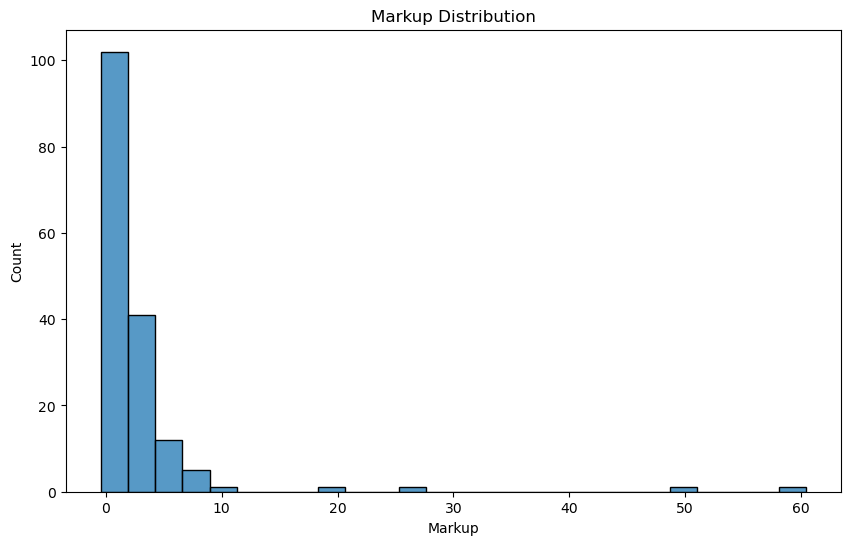

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Markup')
plt.title('Markup Distribution')
plt.show()

### 2. Pair plot of Data

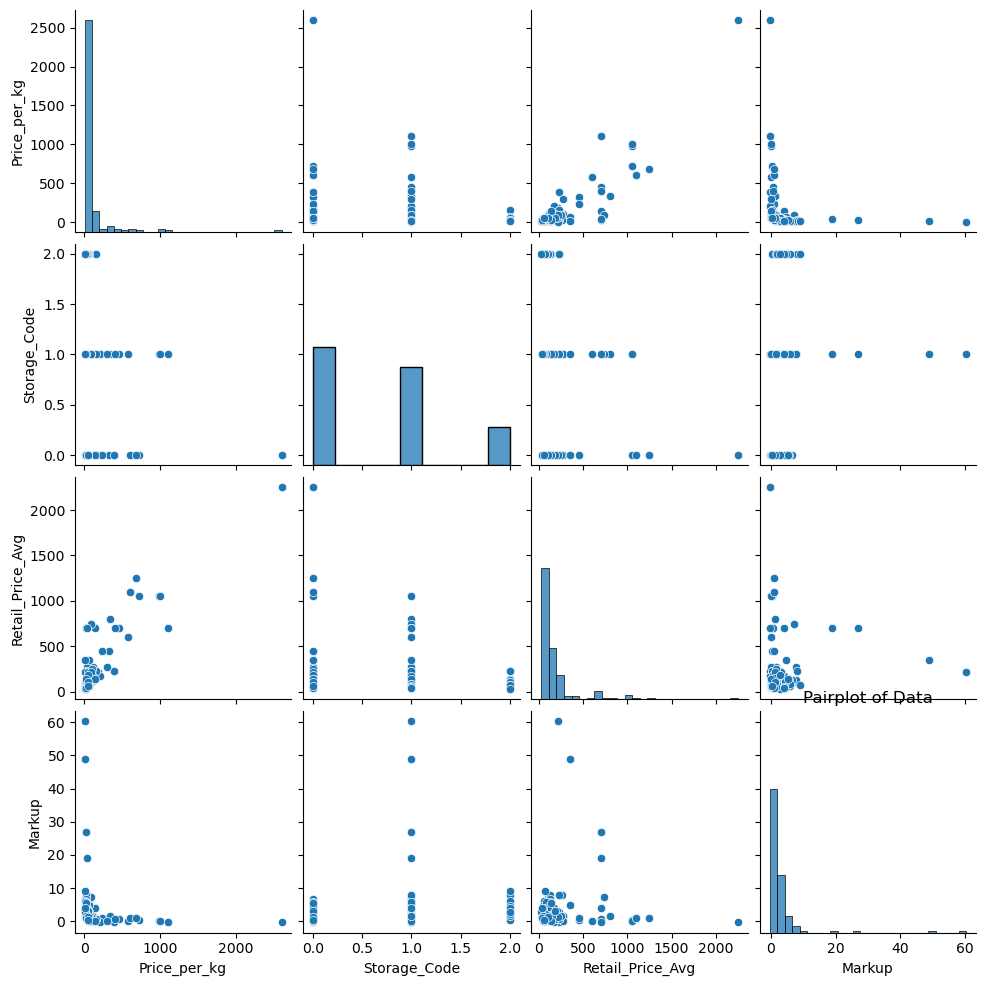

In [31]:
sns.pairplot(data=df)
plt.title('Pairplot of Data')
plt.show()

### 3. Storage Type Distribution

In [32]:
counts = df['Storage_Type'].value_counts()

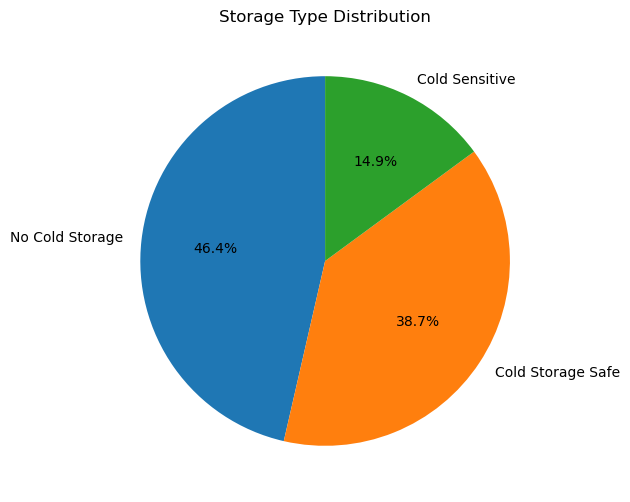

In [33]:
plt.figure(figsize=(10,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Storage Type Distribution')
plt.show()

### 4. Types of Agri Products Distribution

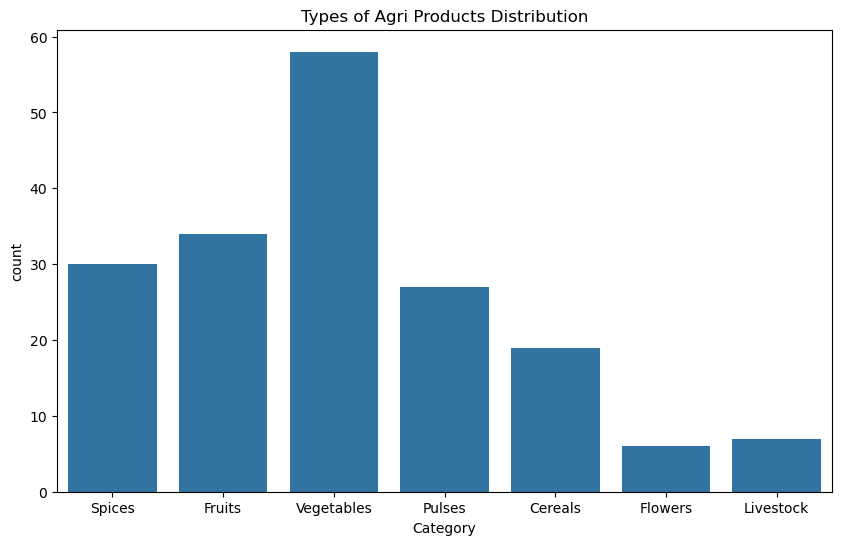

In [34]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df)
plt.title('Types of Agri Products Distribution')
plt.show()

### 5. Market Price Distribution

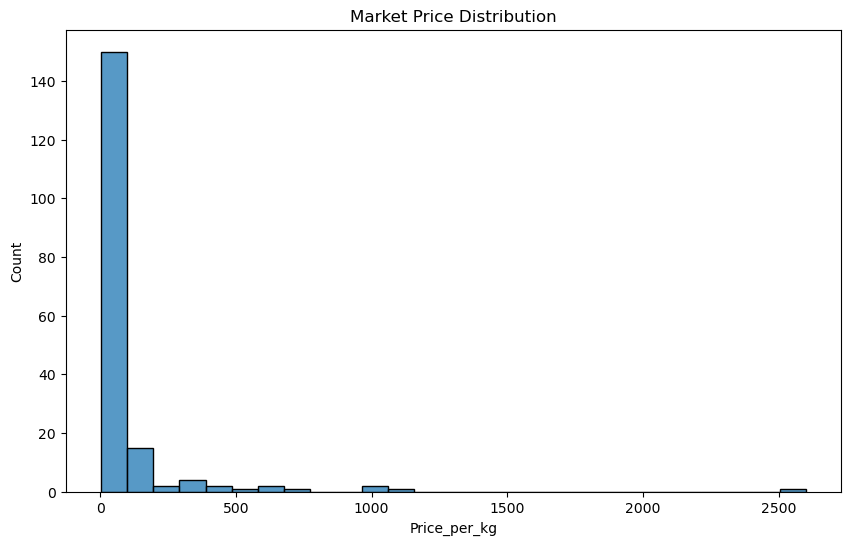

In [35]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price_per_kg'])
plt.title('Market Price Distribution')
plt.show()

### 6. Retail Price Distribution

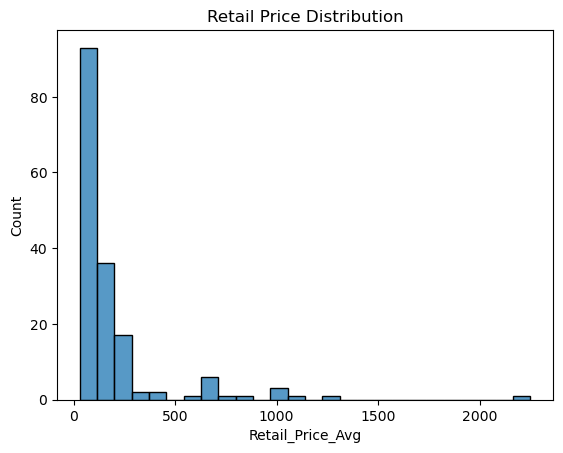

In [36]:
sns.histplot(df['Retail_Price_Avg'])
plt.title('Retail Price Distribution')
plt.show()

### 7. Markup Distribution

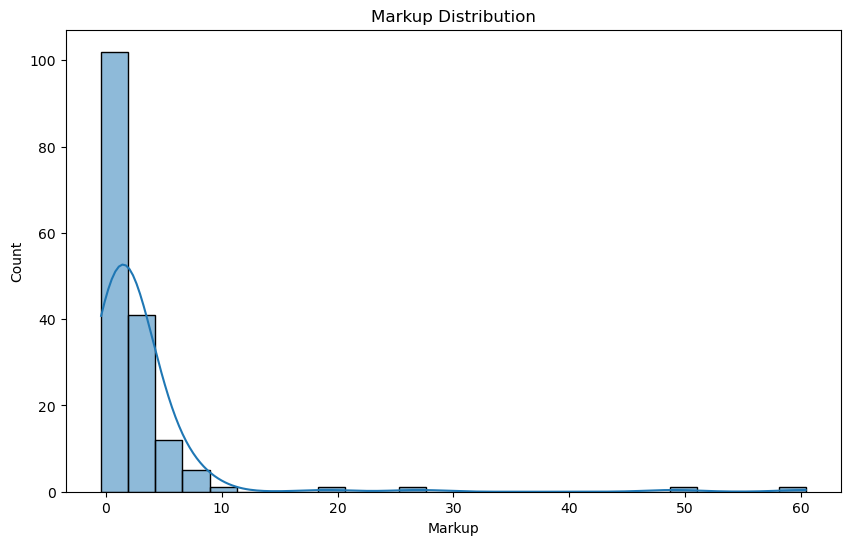

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df['Markup'],kde=True)
plt.title('Markup Distribution')
plt.show()

### 8. Agri Products Seasonal Distribution

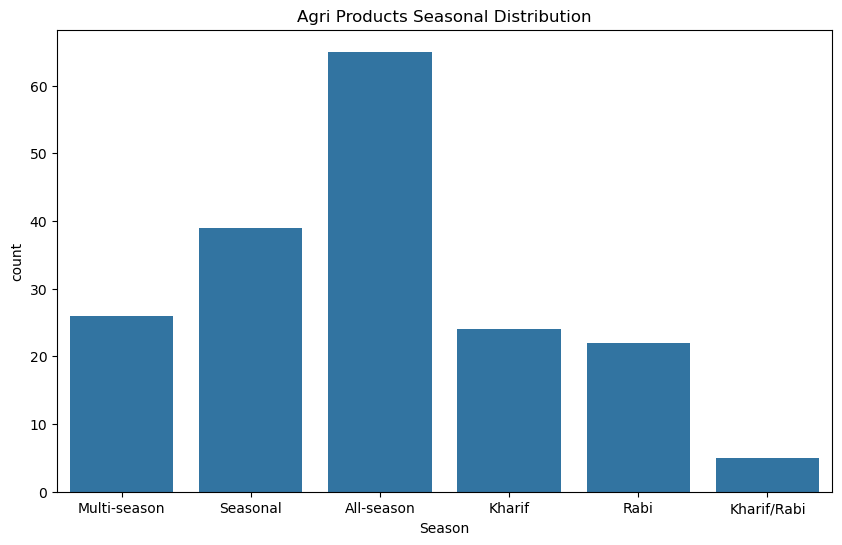

In [38]:
plt.figure(figsize=(10,6))
sns.countplot(x='Season', data=df)
plt.title('Agri Products Seasonal Distribution')
plt.show()

### 9. Relationshipe between Market Price and Retail Price

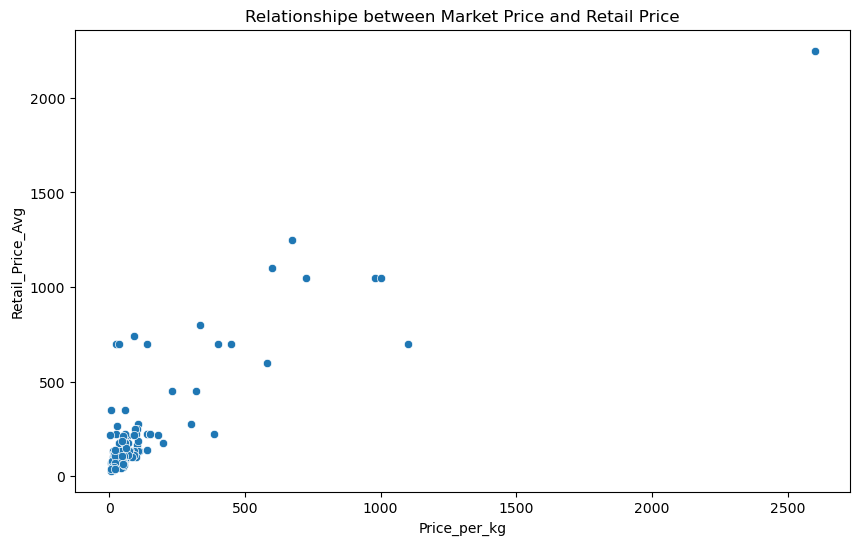

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Price_per_kg',y='Retail_Price_Avg',data=df)
plt.title('Relationshipe between Market Price and Retail Price')
plt.show()

### 10. Market Price Distribution by Category

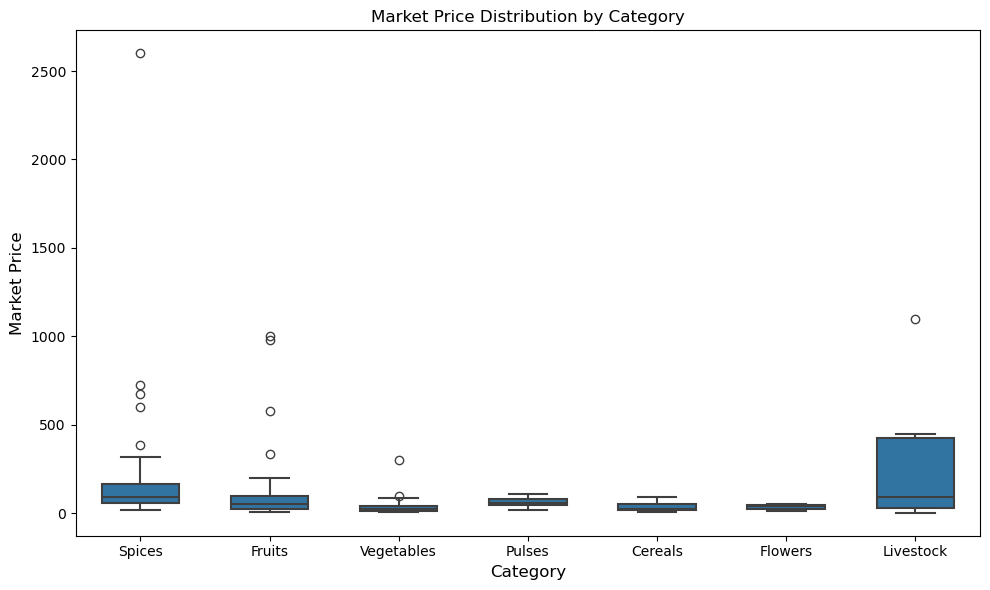

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Price_per_kg",
    width=0.6,
    linewidth=1.5,
)
plt.title("Market Price Distribution by Category")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Market Price", fontsize=12)
plt.tight_layout()
plt.show()

### 11. Market Price Distribution by Season

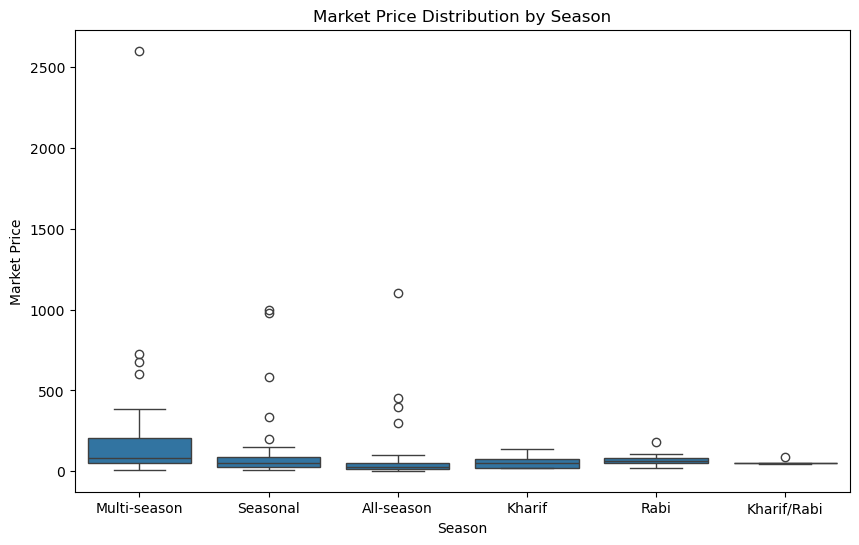

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Season',y='Price_per_kg')
plt.title('Market Price Distribution by Season')
plt.xlabel("Season")
plt.ylabel("Market Price")
plt.show()

### 12. Storage Type and Market Price Distribution

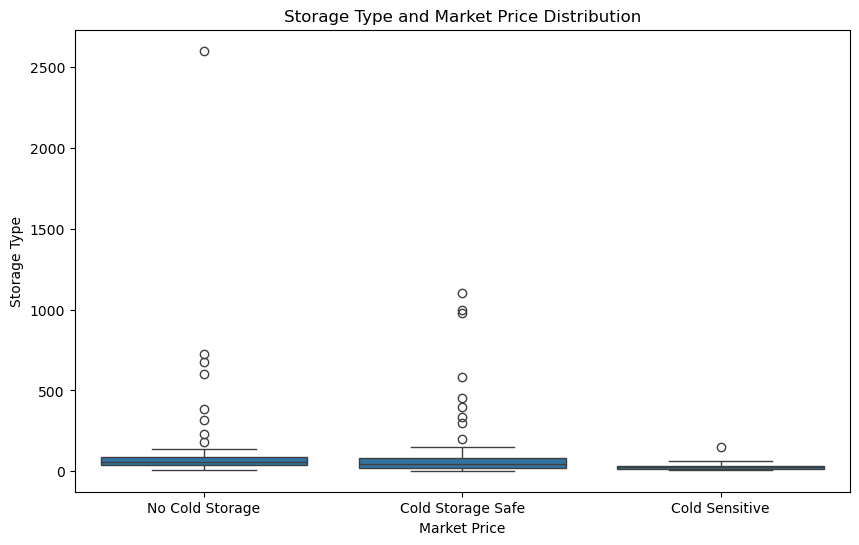

In [42]:
#does storage type affect price
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Storage_Type',y='Price_per_kg')
plt.title('Storage Type and Market Price Distribution')
plt.xlabel('Market Price')
plt.ylabel('Storage Type')
plt.show()

### 13. Correlation Heatmap

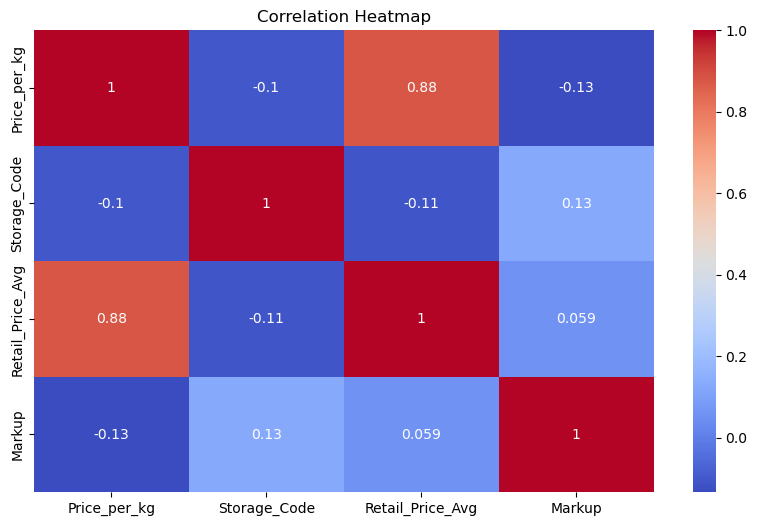

In [43]:
plt.figure(figsize=(10,6))
num_df = df.select_dtypes(include='number')
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 14. Category and Season Heatmap

In [44]:
pivot = df.pivot_table(
    index='Category',
    columns='Season',
    values='Storage_Type',
    aggfunc='count',
    fill_value=0
)

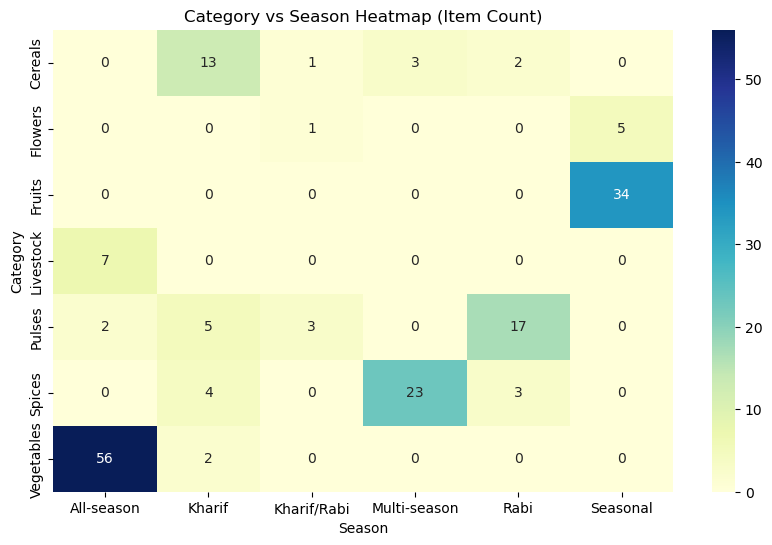

In [45]:
plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')

plt.title("Category vs Season Heatmap (Item Count)")
plt.xlabel("Season")
plt.ylabel("Category")

plt.show()

### 15. Correlation Heatmap: Price, Retail Price & Markup

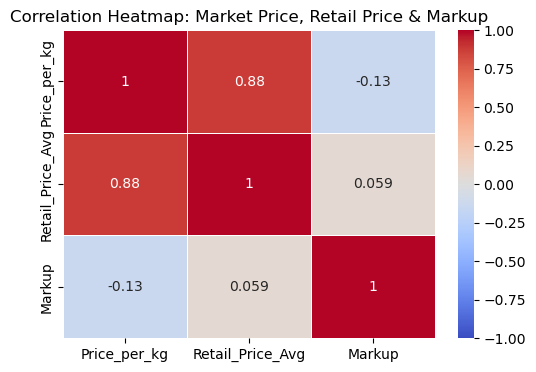

In [46]:
cols = ['Price_per_kg', 'Retail_Price_Avg', 'Markup']
num_df = df[cols]
corr = num_df.corr()
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Market Price, Retail Price & Markup")
plt.show()

### 16. Price Spread per Storage Type

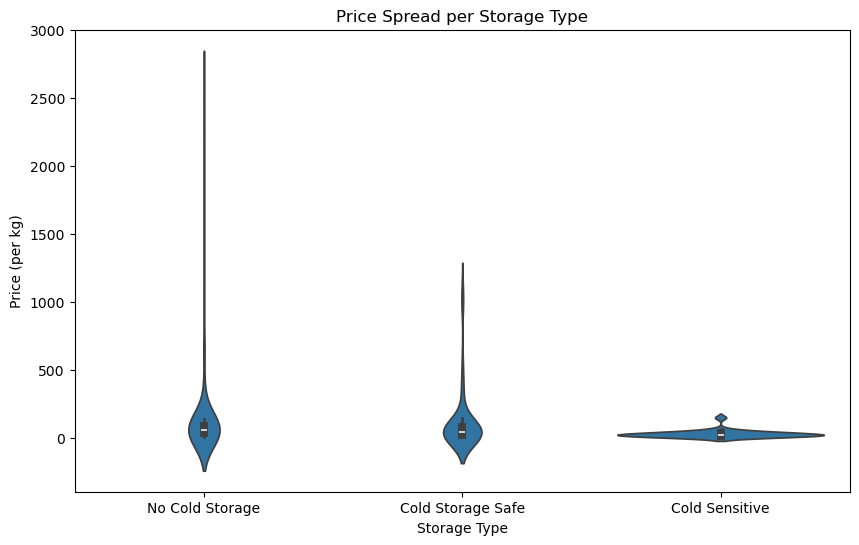

In [47]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Storage_Type',
    y='Price_per_kg',
    data=df,
)

plt.title("Price Spread per Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Price (per kg)")

plt.show()

### 17. Top 10 Expensive Items

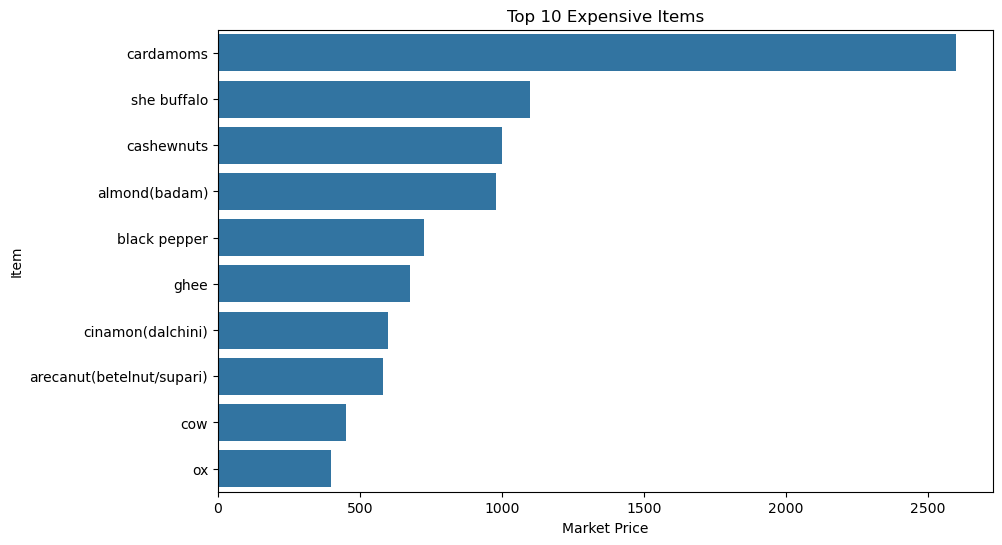

In [48]:
top10 = df.sort_values(by='Price_per_kg', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Price_per_kg',
    y='Name',
)

plt.title("Top 10 Expensive Items")
plt.xlabel("Market Price")
plt.ylabel("Item")

plt.show()

### 18. Average Markup by Category

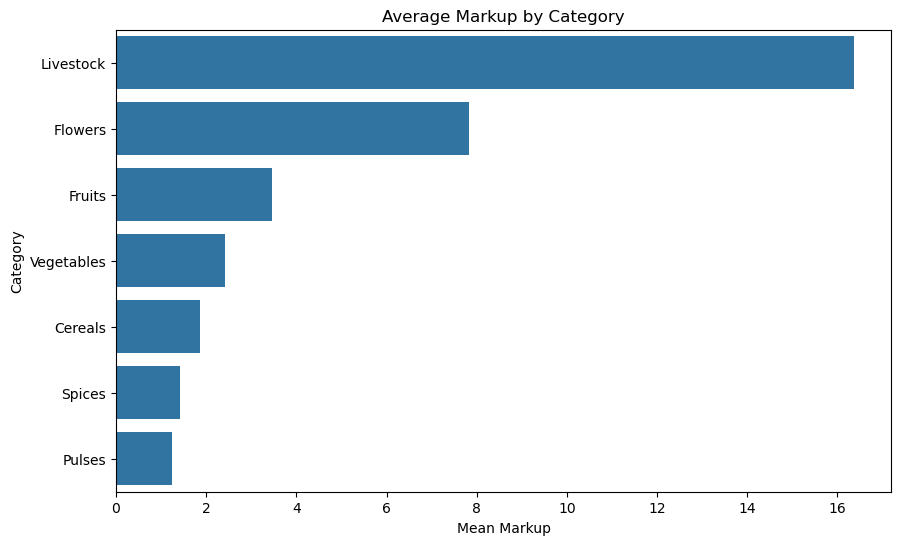

In [49]:
category_markup = df.groupby('Category')['Markup'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_markup.values,
    y=category_markup.index,
)

plt.title("Average Markup by Category")
plt.xlabel("Mean Markup")
plt.ylabel("Category")

plt.show()

### 19. Top 10 Highest Markup Items

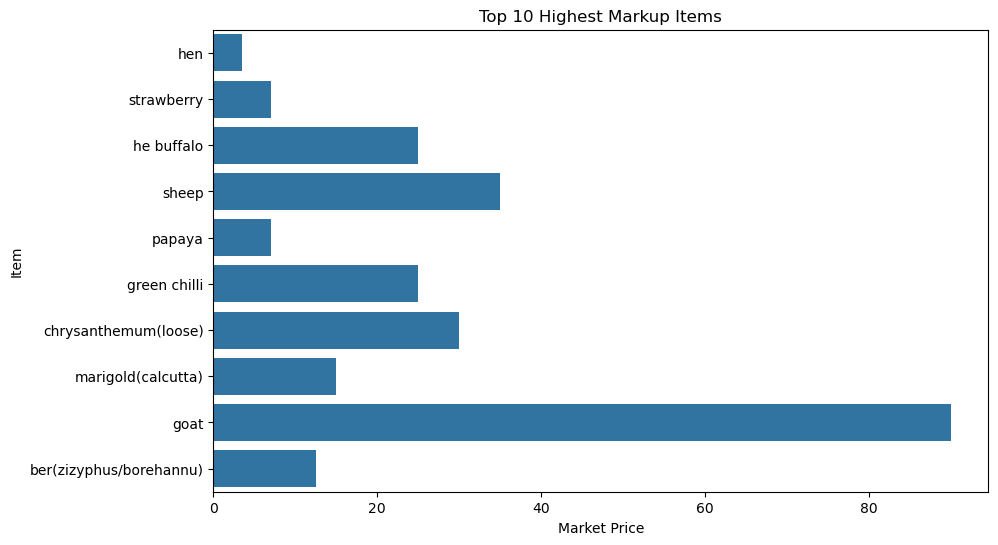

In [50]:
top10 = df.sort_values(by='Markup', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Price_per_kg',
    y='Name',
)

plt.title("Top 10 Highest Markup Items")
plt.xlabel("Market Price")
plt.ylabel("Item")

plt.show()

In [51]:
df.to_csv("agri_products_data.csv", index=False)

## Model Train & Test

In [87]:
df = df.dropna(subset=['Price_per_kg', 'Retail_Price_Avg'])

In [88]:
X=df[['Price_per_kg']]
y=df['Retail_Price_Avg']

### Split data into train and test

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [90]:
model= LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Test model

In [91]:
y_pred = model.predict(X_test)

In [92]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [93]:
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 30430.21483680617
R2 Score: 0.19888835405023442


### Visualize the data

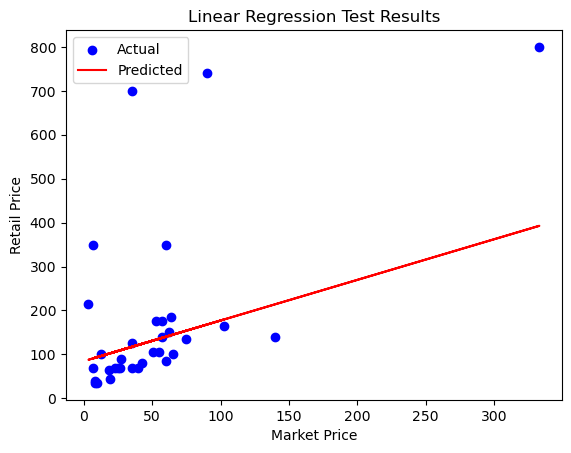

In [94]:
plt.scatter(X_test, y_test, color='blue', label="Actual")
plt.plot(X_test, y_pred, color='red', label="Predicted")
plt.legend()
plt.xlabel("Market Price")
plt.ylabel("Retail Price")
plt.title("Linear Regression Test Results")
plt.show()

In [95]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.92551941]
Intercept: 84.52528326771913


In [69]:
y_pred = model.predict(X)


In [96]:
df.columns

Index(['Name', 'Category', 'Season', 'Price_per_kg', 'Storage_Type',
       'Storage_Code', 'Retail_Price_Avg', 'Markup'],
      dtype='object')

In [98]:
df['Storage_Type'].unique()

array(['No Cold Storage', 'Cold Storage Safe', 'Cold Sensitive'],
      dtype=object)